# PCA clásico, Kernel PCA, LLE e ISOMAP: ejemplos con datos sintéticos

Comparación sobre anillos concéntricos y una superficie en forma de S, incluyendo el efecto del número de vecinos $k$.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import make_s_curve
from sklearn.decomposition import PCA, KernelPCA
from sklearn.manifold import LocallyLinearEmbedding, Isomap, trustworthiness
from sklearn.preprocessing import StandardScaler

%matplotlib inline


## 1. Carga y visualización de los datos

El archivo `datos_sinteticos_anillos.csv` (en esta misma carpeta) contiene 1000
ejemplos con 10 variables (`var_1` a `var_10`) y una columna adicional `grupo` que
indica a qué anillo pertenece cada punto.

Los datos fueron generados sintéticamente con esta estructura: dos anillos
concéntricos en un plano (grupo 0: anillo exterior, grupo 1: anillo interior),
8 variables adicionales de ruido con poca varianza, y una rotación en el espacio de
10 dimensiones que reparte la estructura entre todas las variables. Además, dos de
las variables (`var_3` y `var_8`) están expresadas en unidades distintas a las demás,
por lo que sus valores son cientos o miles de veces más grandes. El script
`generar_datos_sinteticos_anillos.py` de esta carpeta permite regenerarlos o
modificarlos.

La columna `grupo` se usa únicamente para colorear las gráficas: ni PCA ni Kernel PCA
la utilizan, ambos son métodos no supervisados.

In [2]:
# Cargamos el conjunto de datos sintético
datos = pd.read_csv('datos_sinteticos_anillos.csv')

# Separamos las 10 variables (X) de la etiqueta de grupo (y)
X = datos.drop(columns='grupo')
y = datos['grupo'].values

print("Dimensiones del conjunto de datos:", X.shape)
datos.info()

Dimensiones del conjunto de datos: (1000, 10)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   var_1   1000 non-null   float64
 1   var_2   1000 non-null   float64
 2   var_3   1000 non-null   float64
 3   var_4   1000 non-null   float64
 4   var_5   1000 non-null   float64
 5   var_6   1000 non-null   float64
 6   var_7   1000 non-null   float64
 7   var_8   1000 non-null   float64
 8   var_9   1000 non-null   float64
 9   var_10  1000 non-null   float64
 10  grupo   1000 non-null   int64  
dtypes: float64(10), int64(1)
memory usage: 86.1 KB


In [3]:
print(X.describe())

             var_1        var_2        var_3        var_4        var_5  \
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000   
mean      0.000242     0.000208    -0.030552     0.000320     0.000022   
std       0.053139     0.138168     3.127239     0.202942     0.080857   
min      -0.161038    -0.323104    -8.712179    -0.424907    -0.190102   
25%      -0.033084    -0.076927    -2.113730    -0.111684    -0.048964   
50%       0.001903    -0.000087    -0.150649    -0.003254    -0.002381   
75%       0.035064     0.080786     2.185035     0.114481     0.049204   
max       0.142911     0.299356    10.111463     0.448121     0.183342   

             var_6        var_7        var_8        var_9       var_10  
count  1000.000000  1000.000000  1000.000000  1000.000000  1000.000000  
mean      0.000734    -0.001977     0.185379     0.000421     0.000416  
std       0.239389     0.176741   438.564205     0.359733     0.262753  
min      -0.532135    -0.393243  -938.338

In [4]:
# Observe la desviación estándar de cada variable: var_3 y var_8 son más grandes que las demás
X.std().round(2)

var_1       0.05
var_2       0.14
var_3       3.13
var_4       0.20
var_5       0.08
var_6       0.24
var_7       0.18
var_8     438.56
var_9       0.36
var_10      0.26
dtype: float64

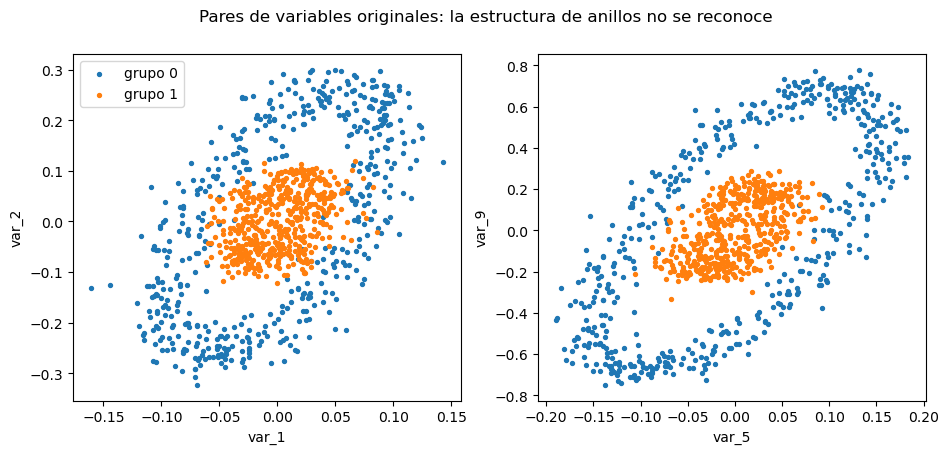

In [5]:
# Si miramos pares de variables originales la estructura de anillos es difícil
# de reconocer: la rotación la repartió entre las 10 variables (a lo sumo se
# intuye una mezcla difusa de los dos grupos)
fig, ejes = plt.subplots(1, 2, figsize=(11, 4.5))
for c, nombre in [(0, 'grupo 0'), (1, 'grupo 1')]:
    ejes[0].scatter(X.loc[y == c, 'var_1'], X.loc[y == c, 'var_2'], s=8, label=nombre)
    ejes[1].scatter(X.loc[y == c, 'var_5'], X.loc[y == c, 'var_9'], s=8, label=nombre)
ejes[0].set_xlabel('var_1'); ejes[0].set_ylabel('var_2')
ejes[1].set_xlabel('var_5'); ejes[1].set_ylabel('var_9')
ejes[0].legend()
plt.suptitle('Pares de variables originales: la estructura de anillos no se reconoce')
plt.show()

## 2. PCA clásico sin escalar

Apliquemos primero PCA directamente sobre los datos, sin ningún preprocesamiento,
para ver qué ocurre. Recuerde que PCA busca las direcciones de mayor varianza; como
`var_3` y `var_8` tienen valores cientos o miles de veces más grandes que el resto,
su varianza domina por completo el análisis.

Varianza explicada por las 2 primeras componentes: 100.00 %


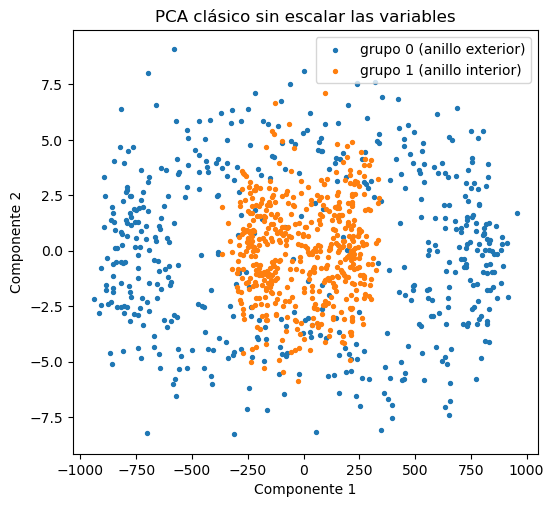

In [6]:
pca_sin_escalar = PCA(n_components=2)
X_pca_sin_escalar = pca_sin_escalar.fit_transform(X)

print('Varianza explicada por las 2 primeras componentes: %.2f %%'
      % (100 * pca_sin_escalar.explained_variance_ratio_.sum()))

plt.figure(figsize=(6, 5.5))
for c, nombre in [(0, 'grupo 0 (anillo exterior)'), (1, 'grupo 1 (anillo interior)')]:
    plt.scatter(X_pca_sin_escalar[y == c, 0], X_pca_sin_escalar[y == c, 1],
                s=8, label=nombre)
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('PCA clásico sin escalar las variables')
plt.legend()
plt.show()

El resultado es una nube sin estructura: las dos componentes quedaron dominadas por
`var_8` y `var_3` (observe las magnitudes de los ejes), que son puro ruido en unidades
grandes, y la estructura de anillos quedó aplastada.

Note un detalle importante: la varianza explicada por las 2 componentes es
prácticamente del 100%, el valor más alto posible, y sin embargo la representación es
inservible. La varianza explicada se mide en las unidades de los datos, así que cuando
las escalas son heterogéneas deja de ser un buen indicador de calidad: explicar mucha
varianza solo significa reproducir las variables de números grandes.

## 3. Escalado de las variables

La solución es llevar todas las variables a una escala comparable antes de aplicar
PCA. Usamos `StandardScaler`, que resta a cada variable su media y la divide por su
desviación estándar, de modo que todas quedan con media 0 y desviación estándar 1.
Así ninguna variable domina el análisis solo por sus unidades de medida.

Varianza explicada por las 2 primeras componentes: 94.19 %


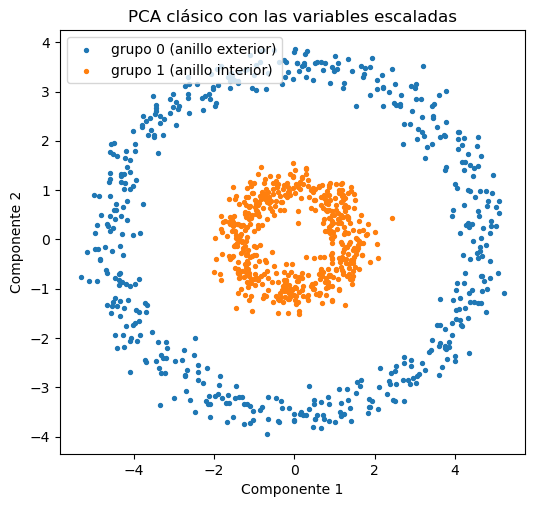

In [7]:
# Escalamos las variables: media 0 y desviación estándar 1 para cada una
escalador = StandardScaler()
X_escalado = escalador.fit_transform(X)

# Repetimos el PCA, ahora sobre los datos escalados
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_escalado)

print('Varianza explicada por las 2 primeras componentes: %.2f %%'
      % (100 * pca.explained_variance_ratio_.sum()))

plt.figure(figsize=(6, 5.5))
for c, nombre in [(0, 'grupo 0 (anillo exterior)'), (1, 'grupo 1 (anillo interior)')]:
    plt.scatter(X_pca[y == c, 0], X_pca[y == c, 1], s=8, label=nombre)
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('PCA clásico con las variables escaladas')
plt.legend()
plt.show()

Con las variables escaladas el panorama cambia por completo: PCA recuperó la
estructura de anillos que estaba escondida entre las 10 variables y dejó de lado las
dimensiones de ruido. Sin embargo, observe que los grupos siguen siendo inseparables:
un anillo rodea al otro. Esto no es un defecto de esta proyección en particular; como
PCA solo puede aplicar transformaciones lineales (rotaciones y proyecciones), y en
toda proyección lineal el anillo exterior seguirá rodeando al interior, no existe
ninguna elección de componentes que separe los dos grupos.

## 4. Kernel PCA

Aplicamos ahora Kernel PCA con kernel gaussiano (RBF). El kernel mide la similitud
entre puntos en términos de distancia. Al hacer PCA sobre esa noción de similitud, el
método puede transformar la geometría de los anillos y producir una representación
donde los grupos resulten separables.

Como el kernel se calcula con las distancias entre puntos, Kernel PCA es sensible a
las escalas. Sin escalar, las distancias quedarían dominadas por `var_3` y `var_8`.
Por eso se aplica sobre los datos ya escalados.

El parámetro `gamma` controla qué tan rápido decae la similitud con la distancia. Su
elección es importante y se analizará más adelante.

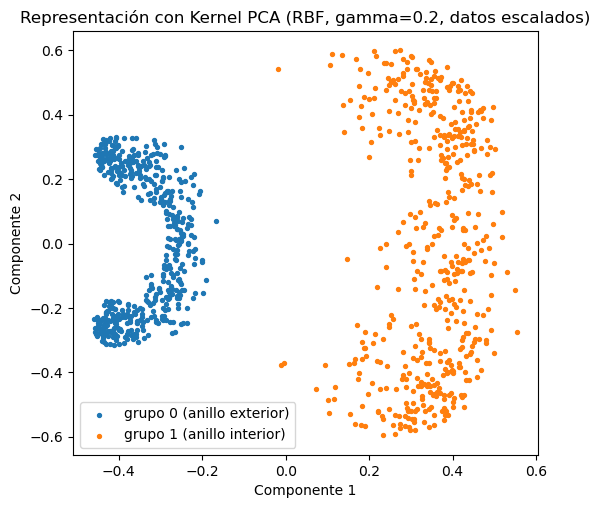

In [8]:
kpca = KernelPCA(n_components=2, kernel='rbf', gamma=0.2)
X_kpca = kpca.fit_transform(X_escalado)

plt.figure(figsize=(6, 5.5))
for c, nombre in [(0, 'grupo 0 (anillo exterior)'), (1, 'grupo 1 (anillo interior)')]:
    plt.scatter(X_kpca[y == c, 0], X_kpca[y == c, 1], s=8, label=nombre)
plt.xlabel('Componente 1')
plt.ylabel('Componente 2')
plt.title('Representación con Kernel PCA (RBF, gamma=0.2, datos escalados)')
plt.legend()
plt.show()

Con la representación de Kernel PCA los dos anillos quedaron convertidos en dos grupos
compactos y separados: la primera componente por sí sola basta para distinguirlos.

Para verlo con claridad, comparamos la distribución de la primera componente de cada
método separada por grupo.

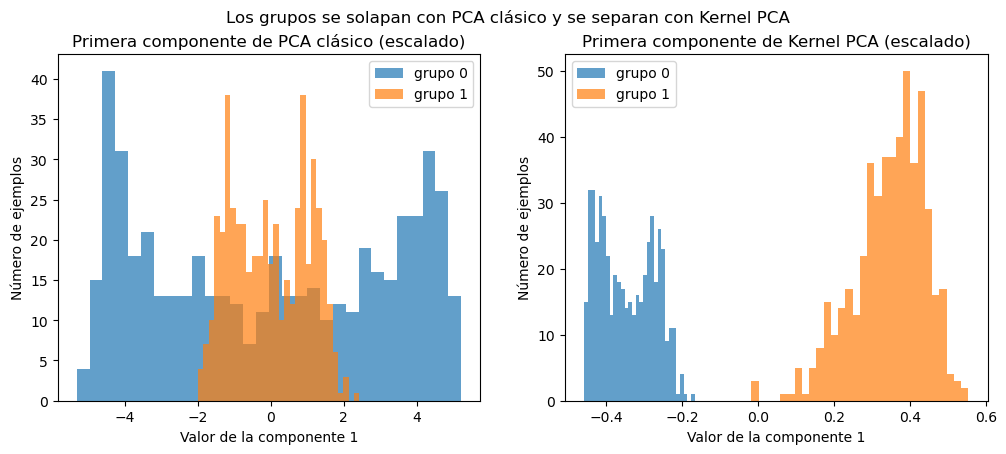

In [9]:
# Histograma de la primera componente de cada metodo, separado por grupo
# (ambos metodos aplicados sobre los datos escalados)
fig, ejes = plt.subplots(1, 2, figsize=(12, 4.5))

for c, nombre in [(0, 'grupo 0'), (1, 'grupo 1')]:
    ejes[0].hist(X_pca[y == c, 0], bins=30, alpha=0.7, label=nombre)
    ejes[1].hist(X_kpca[y == c, 0], bins=30, alpha=0.7, label=nombre)

ejes[0].set_title('Primera componente de PCA clásico (escalado)')
ejes[1].set_title('Primera componente de Kernel PCA (escalado)')
for eje in ejes:
    eje.set_xlabel('Valor de la componente 1')
    eje.set_ylabel('Número de ejemplos')
    eje.legend()
plt.suptitle('Los grupos se solapan con PCA clásico y se separan con Kernel PCA')
plt.show()

## 5. La elección del kernel y sus parámetros importa

La ventaja de Kernel PCA no es automática: depende de elegir un kernel y unos
parámetros adecuados para los datos. Repetimos el ejercicio con tres valores de
`gamma`: uno muy pequeño (el kernel es casi lineal y el resultado se parece al PCA
clásico), el valor adecuado, y uno muy grande (cada punto solo se parece a sus
vecinos inmediatos y la estructura global se pierde).

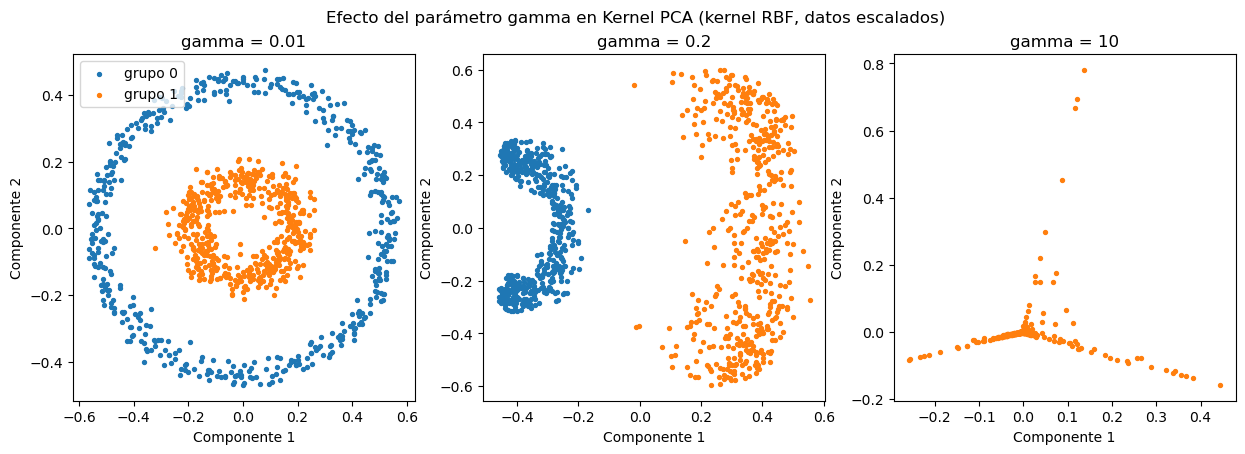

In [10]:
fig, ejes = plt.subplots(1, 3, figsize=(15, 4.5))

for eje, g in zip(ejes, [0.01, 0.2, 10]):
    X_g = KernelPCA(n_components=2, kernel='rbf', gamma=g).fit_transform(X_escalado)
    for c, nombre in [(0, 'grupo 0'), (1, 'grupo 1')]:
        eje.scatter(X_g[y == c, 0], X_g[y == c, 1], s=8, label=nombre)
    eje.set_title('gamma = %g' % g)
    eje.set_xlabel('Componente 1')
    eje.set_ylabel('Componente 2')
ejes[0].legend()
plt.suptitle('Efecto del parámetro gamma en Kernel PCA (kernel RBF, datos escalados)')
plt.show()

### Interpretación de los tres resultados

Para interpretar las tres gráficas conviene recordar qué mide el kernel RBF:
$k(x, x') = e^{-\gamma \, \lVert x - x' \rVert^2}$, la similitud entre dos puntos, que
decae con la distancia entre ellos a una velocidad controlada por `gamma`. De forma
aproximada, dos puntos se consideran "parecidos" cuando su distancia es menor que
$1/\sqrt{\gamma}$; ese valor actúa como el radio de influencia de cada punto.

Como referencia, en el espacio escalado los anillos tienen radios aproximados de 4
(exterior) y 1.3 (interior), así que la separación entre ellos es de unas 2.5 a 3
unidades.

- Con `gamma = 0.01` el radio de influencia es de alrededor de 10 unidades, más
  grande que cualquier distancia en estos datos. Todos los puntos resultan parecidos
  entre sí, el kernel apenas distingue distancias y su comportamiento es casi lineal:
  el resultado reproduce los anillos concéntricos del PCA clásico, sin ganancia
  alguna.

- Con `gamma = 0.2` el radio de influencia es de alrededor de 2 unidades, un valor
  comparable con la separación entre los anillos. Cada punto es similar a los de su
  propio anillo y poco similar a los del otro; esa es exactamente la información que
  el método necesita para separar los dos grupos en la primera componente.

- Con `gamma = 10` el radio de influencia cae a unas 0.3 unidades: cada punto solo
  se parece a sus vecinos inmediatos y resulta casi igual de "distinto" a todos los
  demás, estén en su anillo o en el otro. La noción de estructura global se pierde y
  la representación se degrada: un grupo colapsa en una nube compacta y el otro se
  dispersa sin orden. El resultado es peor que el del PCA clásico.

La lectura general: `gamma` debe estar en sintonía con la escala de las distancias
que definen la estructura de los datos. Ni tan pequeño que todo parezca igual de
similar, ni tan grande que nada lo parezca. Observe además que escalar los datos
también ayuda aquí: al llevar todas las variables a una escala comparable, las
distancias (y por tanto `gamma`) tienen un significado uniforme. En la práctica se
explora un rango de valores (como hicimos aquí) o se selecciona con algún criterio
de validación.

## 6. LLE e ISOMAP sobre los dos anillos concéntricos

Ahora comparamos dos métodos basados en vecindarios.

- LLE intenta preservar relaciones locales de reconstrucción.
- ISOMAP construye un grafo de vecinos y utiliza caminos mínimos para aproximar
  las distancias geodésicas.

En ambos casos, el hiperparámetro `n_neighbors = k` es fundamental porque determina
qué puntos se consideran vecinos en el grafo local.


C:\Users\Unimagdalena\anaconda3\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\Unimagdalena\anaconda3\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])


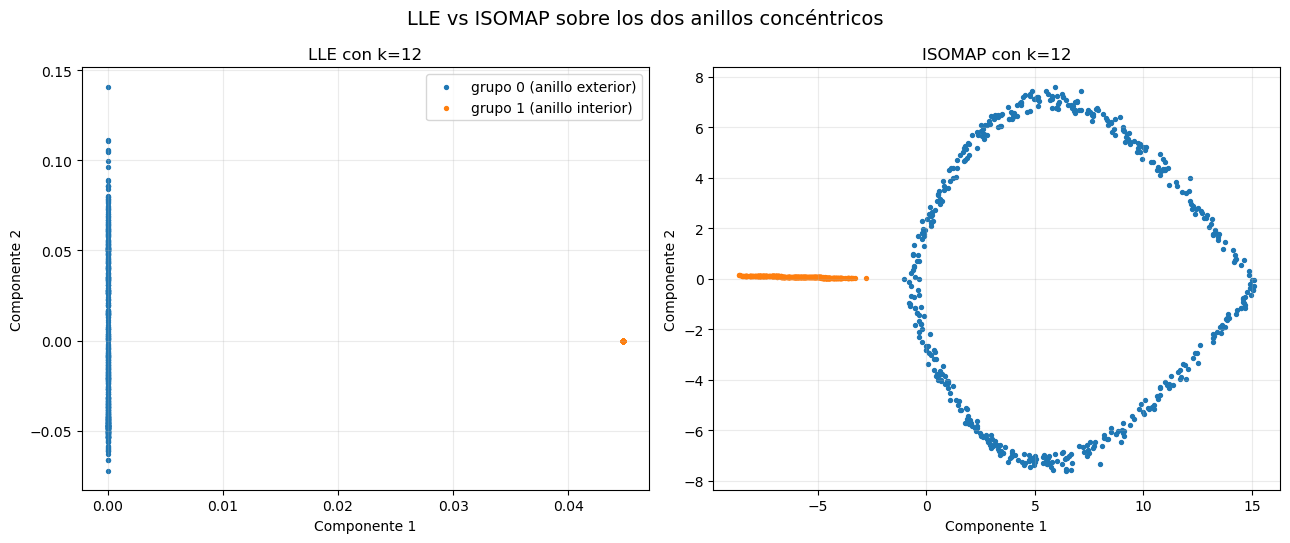

Trustworthiness LLE:    0.7843
Trustworthiness ISOMAP: 0.9189


In [11]:
n_vecinos_anillos = 12

# ----- LLE -----
lle_anillos = LocallyLinearEmbedding(
    n_neighbors=n_vecinos_anillos,
    n_components=2,
    method='standard',
    eigen_solver='arpack',
    random_state=42
)
X_lle_anillos = lle_anillos.fit_transform(X_escalado)

# ----- ISOMAP -----
isomap_anillos = Isomap(
    n_neighbors=n_vecinos_anillos,
    n_components=2,
    eigen_solver='arpack',
    path_method='auto'
)
X_isomap_anillos = isomap_anillos.fit_transform(X_escalado)

fig, ejes = plt.subplots(1, 2, figsize=(13, 5.5))

for eje, representacion, titulo in [
    (ejes[0], X_lle_anillos, 'LLE'),
    (ejes[1], X_isomap_anillos, 'ISOMAP')
]:
    for c, nombre in [(0, 'grupo 0 (anillo exterior)'), (1, 'grupo 1 (anillo interior)')]:
        eje.scatter(
            representacion[y == c, 0],
            representacion[y == c, 1],
            s=8,
            label=nombre
        )
    eje.set_title(f'{titulo} con k={n_vecinos_anillos}')
    eje.set_xlabel('Componente 1')
    eje.set_ylabel('Componente 2')
    eje.grid(True, alpha=0.25)

ejes[0].legend()
fig.suptitle('LLE vs ISOMAP sobre los dos anillos concéntricos', fontsize=14)
plt.tight_layout()
plt.show()

trust_lle_anillos = trustworthiness(
    X_escalado, X_lle_anillos, n_neighbors=n_vecinos_anillos
)
trust_isomap_anillos = trustworthiness(
    X_escalado, X_isomap_anillos, n_neighbors=n_vecinos_anillos
)

print('Trustworthiness LLE:    %.4f' % trust_lle_anillos)
print('Trustworthiness ISOMAP: %.4f' % trust_isomap_anillos)


### Influencia de _k_ en los anillos

El número de vecinos controla la escala local con la que ambos métodos interpretan
la geometría.

- Con un _k_ pequeño, el grafo representa relaciones muy locales, pero puede
  volverse poco conectado o inestable.
- Con un _k_ grande, pueden aparecer conexiones entre puntos de anillos
  diferentes. Esas conexiones actúan como *atajos* que no pertenecen a la geometría
  intrínseca que queremos preservar.

Por esto no existe un valor de _k_ universalmente correcto.


C:\Users\Unimagdalena\anaconda3\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\Unimagdalena\anaconda3\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok are more efficient.
  self._set_intXint(row, col, x.flat[0])
C:\Users\Unimagdalena\anaconda3\Lib\site-packages\sklearn\manifold\_isomap.py:384: UserWarning: The number of connected components of the neighbors graph is 2 > 1. Completing the graph to fit Isomap might be slow. Increase the number of neighbors to avoid this issue.
  self._fit_transform(X)
C:\Users\Unimagdalena\anaconda3\Lib\site-packages\scipy\sparse\_index.py:174: SparseEfficiencyWarning: Changing the sparsity structure of a csr_matrix is expensive. lil and dok

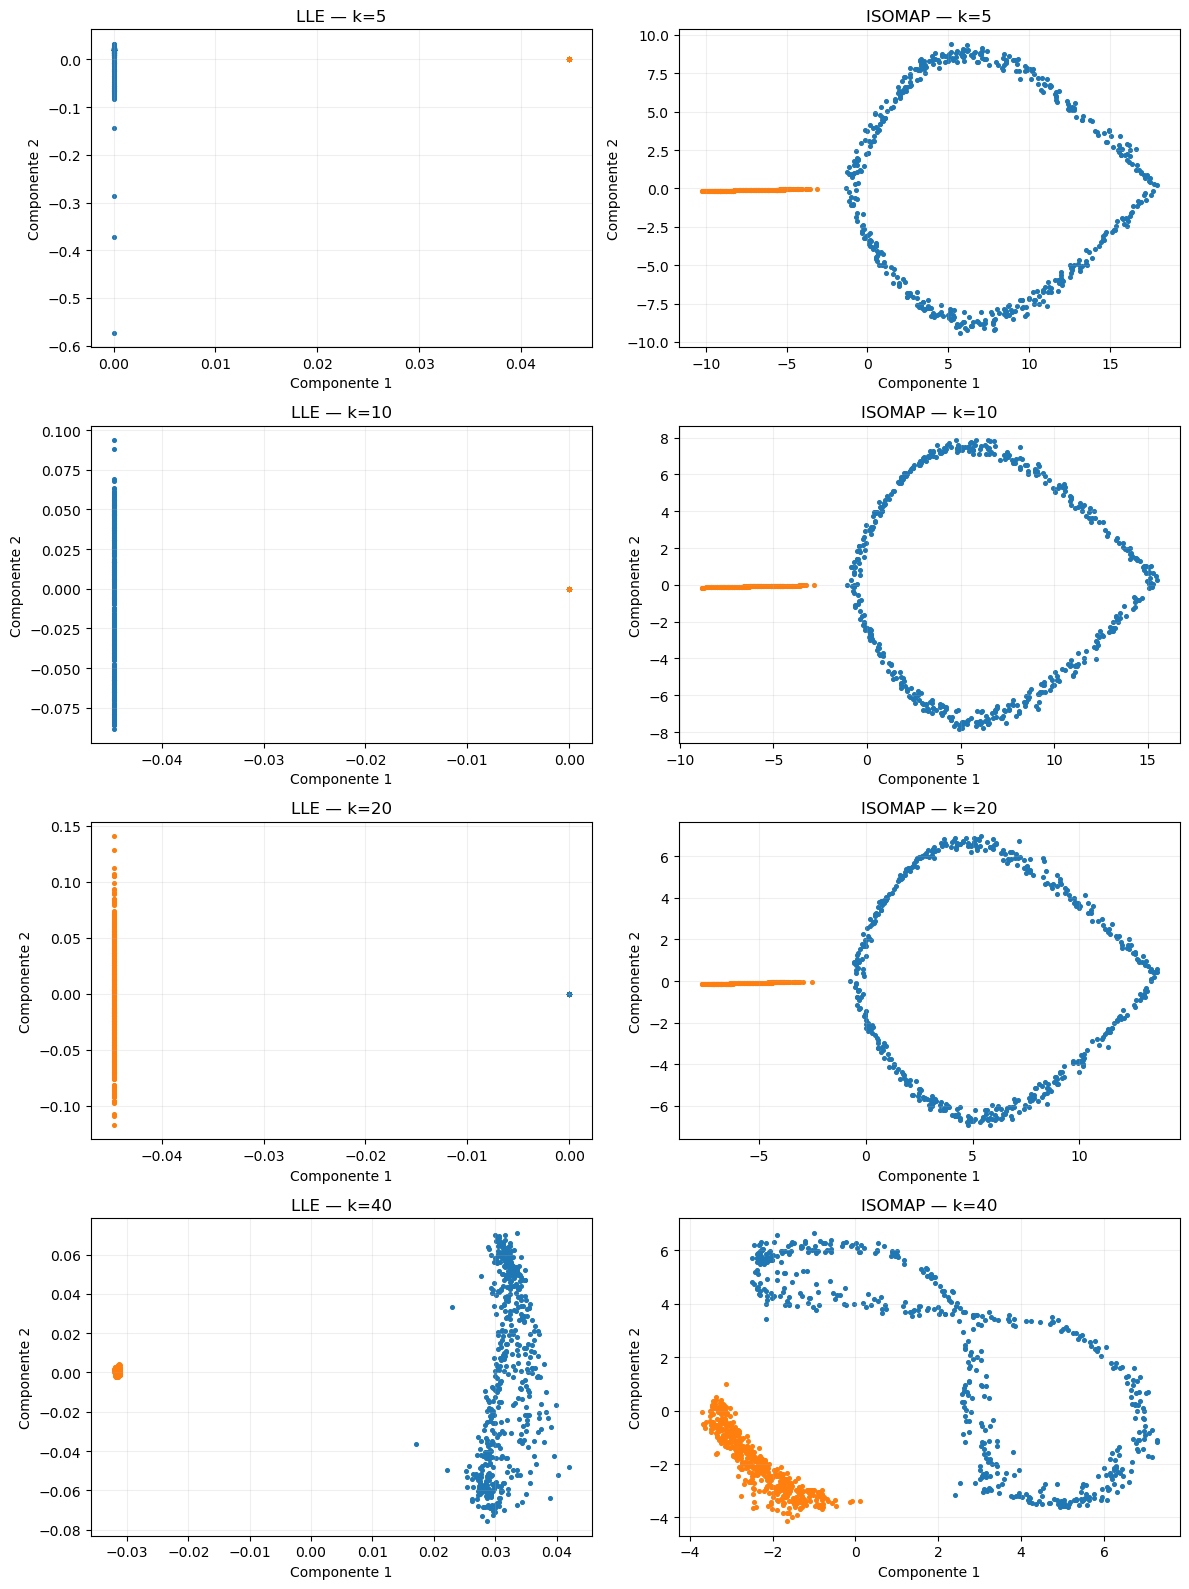

,k,Trustworthiness_LLE,Trustworthiness_ISOMAP
0,5,0.866570,0.915550
1,10,0.780295,0.912262
2,20,0.774088,0.917936
3,40,0.831470,0.911969


In [12]:
valores_k_anillos = [5, 10, 20, 40]

fig, ejes = plt.subplots(
    len(valores_k_anillos), 2,
    figsize=(12, 4 * len(valores_k_anillos))
)

resultados_k_anillos = []

for fila, k in enumerate(valores_k_anillos):

    # LLE
    lle_k = LocallyLinearEmbedding(
        n_neighbors=k,
        n_components=2,
        method='standard',
        eigen_solver='arpack',
        random_state=42
    )
    X_lle_k = lle_k.fit_transform(X_escalado)

    # ISOMAP
    isomap_k = Isomap(
        n_neighbors=k,
        n_components=2,
        eigen_solver='arpack',
        path_method='auto'
    )
    X_isomap_k = isomap_k.fit_transform(X_escalado)

    # Visualización
    for eje, Z, metodo in [
        (ejes[fila, 0], X_lle_k, 'LLE'),
        (ejes[fila, 1], X_isomap_k, 'ISOMAP')
    ]:
        for c in np.unique(y):
            eje.scatter(
                Z[y == c, 0],
                Z[y == c, 1],
                s=7,
                label=f'grupo {c}'
            )
        eje.set_title(f'{metodo} — k={k}')
        eje.set_xlabel('Componente 1')
        eje.set_ylabel('Componente 2')
        eje.grid(True, alpha=0.20)

    resultados_k_anillos.append({
        'k': k,
        'Trustworthiness_LLE': trustworthiness(
            X_escalado, X_lle_k, n_neighbors=min(k, len(X_escalado)-1)
        ),
        'Trustworthiness_ISOMAP': trustworthiness(
            X_escalado, X_isomap_k, n_neighbors=min(k, len(X_escalado)-1)
        )
    })

plt.tight_layout()
plt.show()

resultados_k_anillos = pd.DataFrame(resultados_k_anillos)
resultados_k_anillos


Al comparar las filas, observe no solo si los dos grupos continúan separados, sino
también si la estructura interna se deforma. En ISOMAP, un \(k\) excesivamente grande
puede introducir caminos artificialmente cortos entre regiones que deberían permanecer
separadas. En LLE, un \(k\) demasiado grande hace menos válida la hipótesis de
linealidad local.


## 7. Superficie en forma de S

Los anillos permiten estudiar separación no lineal, pero no representan el escenario
más natural para LLE porque forman dos manifolds cerrados y potencialmente
desconectadas.

Ahora generamos una sola superficie continua en forma de S inmersa en tres
dimensiones. El objetivo es reducirla a dos dimensiones y comparar PCA, Kernel PCA y
LLE.

La variable `t_s` indica la posición de cada punto a lo largo de la superficie y se
utiliza únicamente como escala de color. Una representación adecuada debería conservar
un cambio gradual de color y evitar mezclar regiones alejadas sobre el manifold.

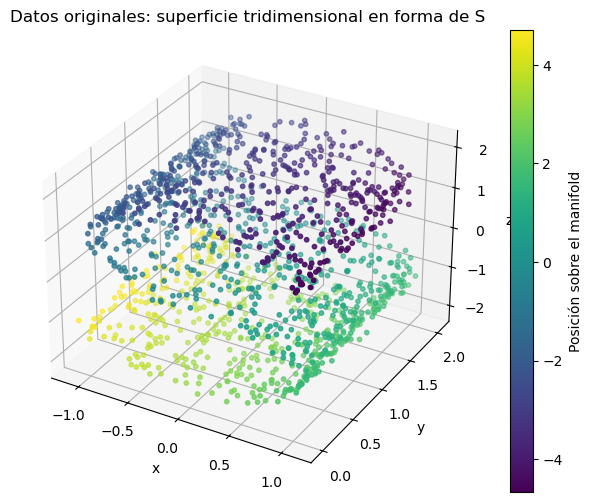

In [13]:
X_s, t_s = make_s_curve(
    n_samples=1500,
    noise=0.04,
    random_state=42
)

escalador_s = StandardScaler()
X_s_escalado = escalador_s.fit_transform(X_s)

fig = plt.figure(figsize=(8, 6))
eje = fig.add_subplot(111, projection='3d')

dispersion = eje.scatter(
    X_s[:, 0],
    X_s[:, 1],
    X_s[:, 2],
    c=t_s,
    cmap='viridis',
    s=10
)

eje.set_xlabel('x')
eje.set_ylabel('y')
eje.set_zlabel('z')
eje.set_title('Datos originales: superficie tridimensional en forma de S')
fig.colorbar(dispersion, ax=eje, label='Posición sobre el manifold')
plt.show()

### Reducción a dos dimensiones: PCA, Kernel PCA, LLE e ISOMAP

La S-curve es especialmente útil para comparar LLE e ISOMAP porque constituye un
manifold continuo y curvo. ISOMAP intenta preservar distancias geodésicas globales,
mientras que LLE reconstruye cada observación a partir de sus vecinos inmediatos.


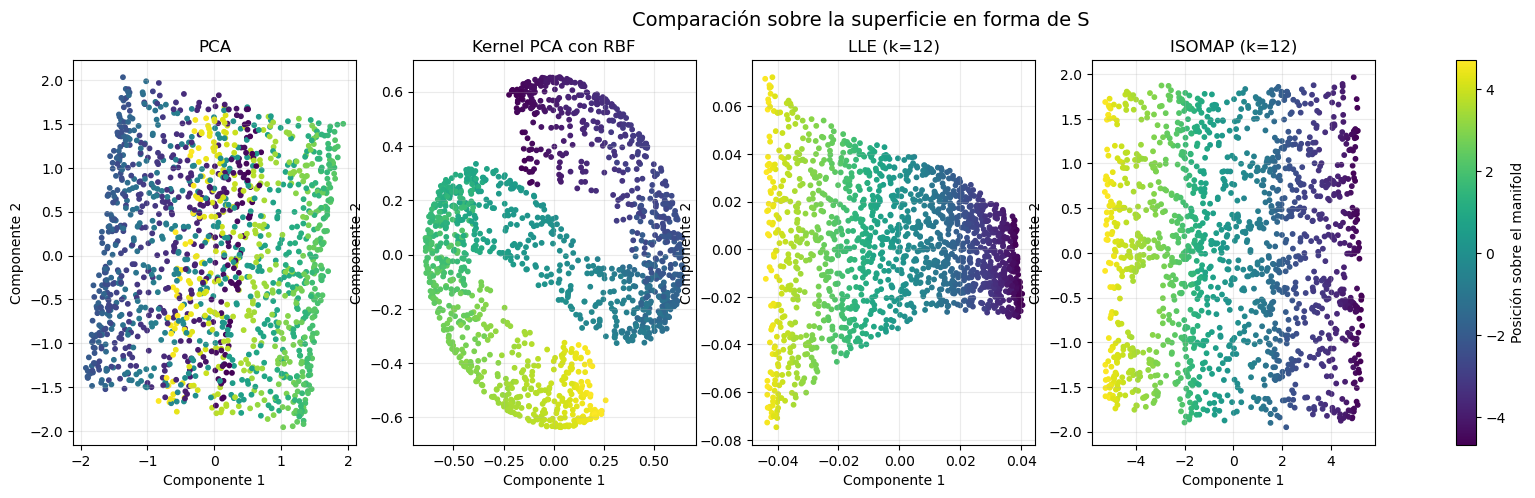

In [14]:
pca_s = PCA(n_components=2)
X_s_pca = pca_s.fit_transform(X_s_escalado)

kpca_s = KernelPCA(
    n_components=2,
    kernel='rbf',
    gamma=0.2
)
X_s_kpca = kpca_s.fit_transform(X_s_escalado)

n_vecinos_s = 12

lle_s = LocallyLinearEmbedding(
    n_neighbors=n_vecinos_s,
    n_components=2,
    method='standard',
    eigen_solver='arpack',
    random_state=42
)
X_s_lle = lle_s.fit_transform(X_s_escalado)

isomap_s = Isomap(
    n_neighbors=n_vecinos_s,
    n_components=2,
    eigen_solver='arpack',
    path_method='auto'
)
X_s_isomap = isomap_s.fit_transform(X_s_escalado)

fig, ejes = plt.subplots(1, 4, figsize=(21, 5))

resultados = [
    (X_s_pca, 'PCA'),
    (X_s_kpca, 'Kernel PCA con RBF'),
    (X_s_lle, f'LLE (k={n_vecinos_s})'),
    (X_s_isomap, f'ISOMAP (k={n_vecinos_s})')
]

for eje, (representacion, titulo) in zip(ejes, resultados):
    dispersion = eje.scatter(
        representacion[:, 0],
        representacion[:, 1],
        c=t_s,
        cmap='viridis',
        s=10
    )
    eje.set_title(titulo)
    eje.set_xlabel('Componente 1')
    eje.set_ylabel('Componente 2')
    eje.grid(True, alpha=0.25)

fig.colorbar(
    dispersion,
    ax=ejes.ravel().tolist(),
    label='Posición sobre el manifold'
)
fig.suptitle('Comparación sobre la superficie en forma de S', fontsize=14)
plt.show()


PCA realiza una proyección lineal. Como consecuencia, distintas partes de la superficie que estaban separadas en el espacio tridimensional quedan superpuestas en el plano. La mezcla de colores en varias regiones muestra que PCA no logra desplegar adecuadamente la estructura curva de los datos.

Kernel PCA con kernel RBF representa mejor la geometría no lineal que PCA. Los colores siguen una transición más organizada y disminuye la superposición entre regiones alejadas de la superficie original. Sin embargo, la representación conserva una forma curva y circular, por lo que no puede interpretarse como un despliegue completo de la superficie.

LLE produce una representación en la que la transición de colores es continua y ordenada desde un extremo hasta el otro. Esto indica que los puntos que eran vecinos sobre la superficie original permanecen próximos en el espacio reducido. Aunque la forma obtenida no es rectangular y presenta una deformación global, LLE logra desplegar el manifold y conservar mejor su estructura local.

En conjunto, el ejemplo muestra que PCA resulta limitado cuando los datos se encuentran sobre un manifold no lineal, mientras que Kernel PCA y LLE capturan mejor dicha estructura. LLE destaca especialmente por conservar los vecindarios locales y el orden de los puntos a lo largo de la superficie.

Las escalas y orientaciones de los ejes no deben compararse directamente entre los métodos, ya que las coordenadas obtenidas por cada técnica tienen significados diferentes. La evaluación debe centrarse en la conservación de la estructura, los vecindarios y la continuidad de los colores.

### Evaluación de la preservación local

La métrica `trustworthiness` evalúa si los vecinos observados en el espacio reducido
también eran vecinos en el espacio original.

Su valor se encuentra entre 0 y 1. Valores más cercanos a 1 indican una mejor
preservación de los vecindarios. Esta métrica favorece el objetivo de LLE y no debe
interpretarse como una medida universal de calidad.

In [15]:
k_evaluacion = 12

resultados_trustworthiness = pd.DataFrame(
    {
        'Método': ['PCA', 'Kernel PCA', 'LLE', 'ISOMAP'],
        'Trustworthiness': [
            trustworthiness(X_s_escalado, X_s_pca, n_neighbors=k_evaluacion),
            trustworthiness(X_s_escalado, X_s_kpca, n_neighbors=k_evaluacion),
            trustworthiness(X_s_escalado, X_s_lle, n_neighbors=k_evaluacion),
            trustworthiness(X_s_escalado, X_s_isomap, n_neighbors=k_evaluacion)
        ]
    }
)

resultados_trustworthiness


,Método,Trustworthiness
0,PCA,0.854768
1,Kernel PCA,0.918744
2,LLE,0.997682
3,ISOMAP,0.999723


### Interpretación de la comparación

PCA aplana la superficie mediante una proyección lineal y puede superponer regiones
que están separadas sobre el manifold.

Kernel PCA puede capturar parte de la curvatura, pero el resultado depende del kernel
y de sus parámetros.

LLE utiliza relaciones de reconstrucción entre vecinos y busca ensamblar esas
relaciones locales en una representación global.

ISOMAP utiliza el grafo de vecinos para calcular caminos mínimos y aproximar
distancias geodésicas. En una estructura continua como la S-curve, esto puede
permitir desplegar el manifold conservando mejor su organización global.

Ninguno de los dos métodos es independiente de \(k\). El siguiente experimento muestra
cómo cambia la representación cuando modificamos el número de vecinos.


### Influencia de \(k\) sobre la S-curve


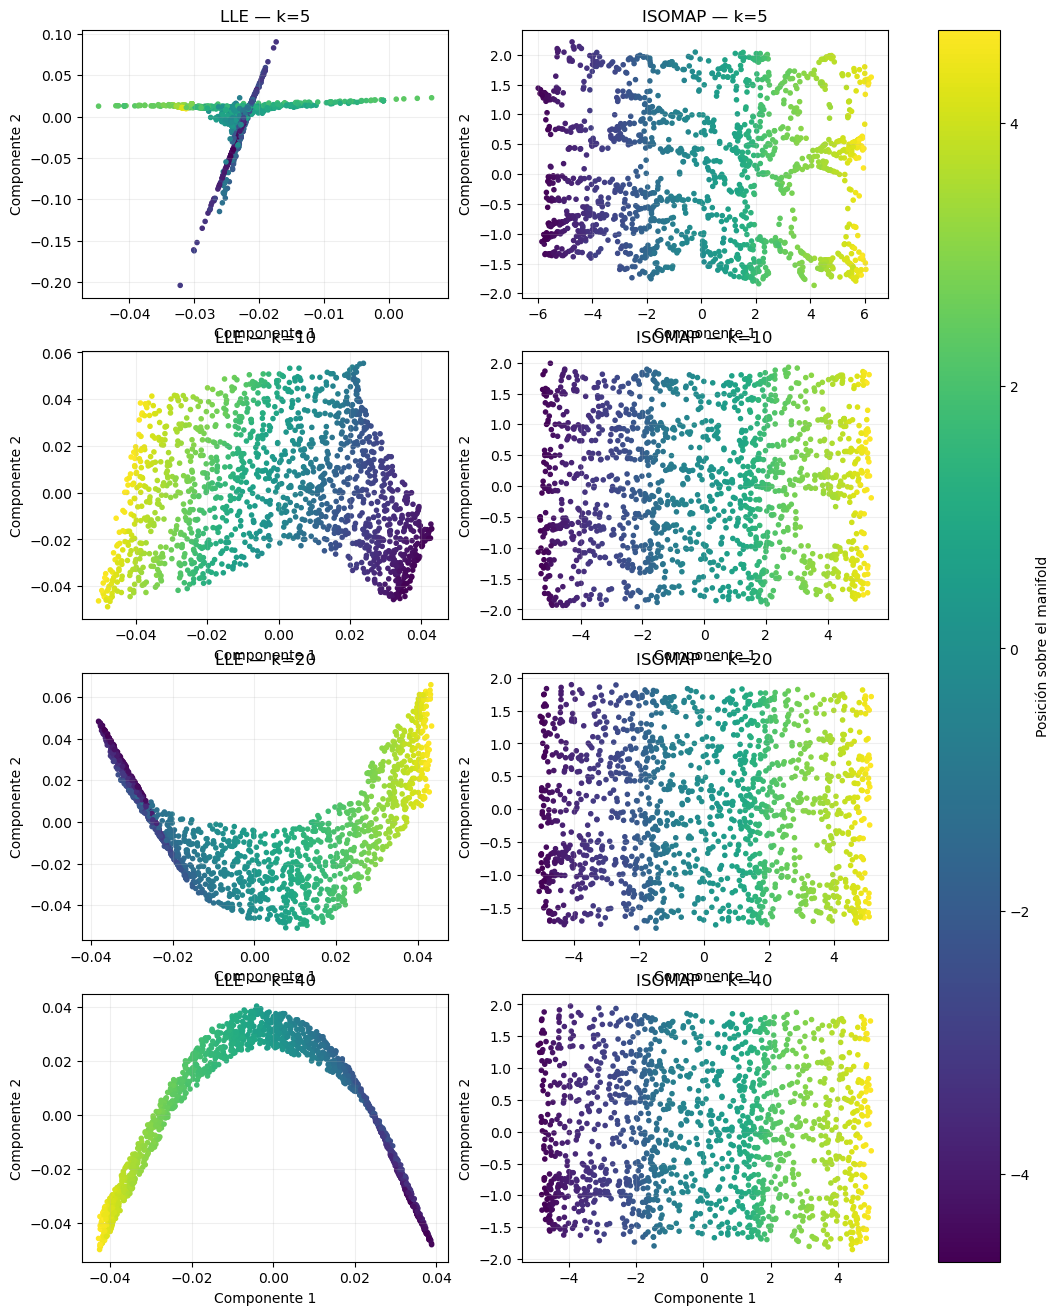

,k,Trustworthiness_LLE,Trustworthiness_ISOMAP
0,5,0.861713,0.999015
1,10,0.997574,0.999714
2,20,0.956904,0.999799
3,40,0.919003,0.999747


In [16]:
valores_k_s = [5, 10, 20, 40]

fig, ejes = plt.subplots(
    len(valores_k_s), 2,
    figsize=(13, 4 * len(valores_k_s))
)

resultados_k_s = []

for fila, k in enumerate(valores_k_s):

    lle_k = LocallyLinearEmbedding(
        n_neighbors=k,
        n_components=2,
        method='standard',
        eigen_solver='arpack',
        random_state=42
    )
    X_lle_k = lle_k.fit_transform(X_s_escalado)

    isomap_k = Isomap(
        n_neighbors=k,
        n_components=2,
        eigen_solver='arpack',
        path_method='auto'
    )
    X_isomap_k = isomap_k.fit_transform(X_s_escalado)

    for eje, Z, metodo in [
        (ejes[fila, 0], X_lle_k, 'LLE'),
        (ejes[fila, 1], X_isomap_k, 'ISOMAP')
    ]:
        dispersion = eje.scatter(
            Z[:, 0],
            Z[:, 1],
            c=t_s,
            cmap='viridis',
            s=9
        )
        eje.set_title(f'{metodo} — k={k}')
        eje.set_xlabel('Componente 1')
        eje.set_ylabel('Componente 2')
        eje.grid(True, alpha=0.20)

    resultados_k_s.append({
        'k': k,
        'Trustworthiness_LLE': trustworthiness(
            X_s_escalado, X_lle_k, n_neighbors=k
        ),
        'Trustworthiness_ISOMAP': trustworthiness(
            X_s_escalado, X_isomap_k, n_neighbors=k
        )
    })

fig.colorbar(
    dispersion,
    ax=ejes.ravel().tolist(),
    label='Posición sobre el manifold'
)
plt.show()

resultados_k_s = pd.DataFrame(resultados_k_s)
resultados_k_s


### ¿Qué observar al variar _k_?

Si _k_ es muy pequeño, cada método dispone de información extremadamente local.
El grafo puede quedar débilmente conectado y la representación puede volverse
inestable.

Con valores intermedios de _k_, los vecinos suelen representar correctamente la
geometría local y es posible recuperar mejor la estructura de la S.

Si _k_ es demasiado grande, puntos situados en pliegues distintos de la S pueden
convertirse en vecinos en el espacio euclidiano. En ISOMAP esas conexiones generan
_shortcuts_ y alteran las distancias geodésicas. En LLE, los vecindarios dejan de ser
suficientemente locales y la aproximación lineal pierde validez.

Por tanto, _k_ controla un compromiso entre onectividad del grafo y
localidad de los vecindarios.
